In [2]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=0
%pylab inline
%load_ext autoreload
%autoreload 2

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=0
%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [1]:
from pathlib import Path
import pickle
import pandas as pd
from tqdm import tqdm
import networkx as nx
from allensdk.core.cell_types_cache import CellTypesCache
import numpy as np

In [3]:
from ssl_neuron.data.data_utils import connect_graph, remove_axon, rotate_cell
from ssl_neuron.utils import neighbors_to_adjacency, plot_neuron

In [ ]:
# Input: the axon-pruned subsampled SWCs produced by plot_healed_subsample.py
# (prune_axon=True in __main__). These already have axons + their descendants
# + type-0 nodes removed, so no further pruning is needed here.
data_path = "/nfs/data8/chuyu/data/20230422_160839/connectome/skeletons/healed_syns_swc/swc/subsampled_swcs_no_axon"
file_list = list(Path(data_path).glob("*.swc"))

neuron_ids = [int(f.stem.split("_")[1]) for f in file_list]


In [5]:
len(neuron_ids)

234

#### Preprocess cells

In [ ]:
# SWC type column convention (from collaborator):
#   1 = soma, 2 = axon, 3 = dendrite, 7 = synapse
# In this notebook the inputs are already axon-free (see data_path), so only
# soma / dendrite / synapse slots get populated. We still encode as length-4
# one-hot with the same TYPE_TO_IDX as the full-skeleton notebook, so the
# feature dim stays consistent across datasets.
TYPE_TO_IDX = {1: 0, 2: 1, 3: 2, 7: 3}


def read_swc_file(file_path, correction=True, downscale=1000):
    """Read SWC file and return morphology as a pandas DataFrame.

    The 'type' column is remapped via TYPE_TO_IDX so downstream code can
    use it directly as a one-hot index into a length-4 vector.
    """
    columns = ['id', 'type', 'x', 'y', 'z', 'radius', 'parent']
    morphology = pd.read_csv(file_path, delim_whitespace=True, comment='#', names=columns)
    morphology[['x', 'y', 'z', 'radius']] = morphology[['x', 'y', 'z', 'radius']] / downscale

    if correction:
        morphology.loc[morphology['parent'] == -1, 'type'] = 1
        id_map = {old_id: new_id for new_id, old_id in enumerate(morphology['id'])}
        morphology['id'] = morphology['id'].map(id_map)
        morphology['parent'] = morphology['parent'].map(lambda x: id_map[x] if x in id_map else -1)
        morphology = morphology.sort_values('id').reset_index(drop=True)
        morphology['id'] = morphology.index

    unknown = set(morphology['type'].unique()) - set(TYPE_TO_IDX)
    assert not unknown, f"Unexpected SWC type values: {unknown}"
    morphology['type'] = morphology['type'].map(TYPE_TO_IDX).astype(int)

    return morphology


In [ ]:
which_cell = 0
cell_id = neuron_ids[which_cell]
path = Path('./skeletons/', str(cell_id))
path.mkdir(parents=True, exist_ok=True)
# read from swc file
file_name  = file_list[which_cell]
morphology = read_swc_file(file_name, correction=True)

In [ ]:
file_name

PosixPath('/nfs/data8/chuyu/data/20230422_160839/connectome/swc/subsampled_swcs/neuron_4819023_scale2_healed_subsampled.swc')

In [ ]:
morphology

,id,type,x,y,z,radius,parent
0,0,1,69.526201,225.812676,132.465295,-0.001,-1
1,1,0,66.120000,227.440000,129.950000,-0.001,0
2,2,0,71.360000,228.920000,129.750000,-0.001,0
3,3,0,71.000000,230.040000,131.600000,-0.001,0
4,4,0,71.400000,228.960000,129.750000,-0.001,2
...,...,...,...,...,...,...,...
2995,2995,0,81.400000,91.600000,207.450000,-0.001,2994
2996,2996,0,80.920000,91.280000,208.250000,-0.001,2995
2997,2997,0,80.880000,91.280000,208.350000,-0.001,2996
2998,2998,0,80.800000,91.120000,208.600000,-0.001,2997


In [ ]:
# ensure integer ids if needed
morphology['id'] = morphology['id'].astype(int)
morphology['parent'] = morphology['parent'].astype(int)

# build map: parent_id -> [child_id1, child_id2, ...]
children_map = (morphology.loc[morphology['parent'] != -1]
                           .groupby('parent')['id']
                           .apply(list)
                           .to_dict())

# assign children lists to each row; use .apply to get fresh lists per row
morphology['children'] = morphology['id'].apply(lambda _id: list(children_map.get(_id, [])))

In [ ]:
morphology

,id,type,x,y,z,radius,parent,children
0,0,1,69.526201,225.812676,132.465295,-0.001,-1,"[1, 2, 3]"
1,1,0,66.120000,227.440000,129.950000,-0.001,0,[5]
2,2,0,71.360000,228.920000,129.750000,-0.001,0,"[4, 11]"
3,3,0,71.000000,230.040000,131.600000,-0.001,0,[6]
4,4,0,71.400000,228.960000,129.750000,-0.001,2,[7]
...,...,...,...,...,...,...,...,...
2995,2995,0,81.400000,91.600000,207.450000,-0.001,2994,[2996]
2996,2996,0,80.920000,91.280000,208.250000,-0.001,2995,[2997]
2997,2997,0,80.880000,91.280000,208.350000,-0.001,2996,[2998]
2998,2998,0,80.800000,91.120000,208.600000,-0.001,2997,[2999]


In [ ]:
# Process graph. Inputs are already axon-free, so no remove_axon call here.
neighbors = {}
idx2node = {}
for i, item in enumerate(morphology.to_dict(orient='records')):
    sec_type = [0, 0, 0, 0]
    sec_type[item['type']] = 1
    feat = tuple([item['x'], item['y'], item['z'], item['radius']]) + tuple(sec_type)
    idx2node[i] = feat

    neighbors[i] = set(item['children'])
    if item['parent'] >= 0:
        neighbors[i].add(item['parent'])

features = np.array(list(idx2node.values()))


In [ ]:
len(neighbors.keys())

3000

In [ ]:
# Test if graph is connected.
adj_matrix = neighbors_to_adjacency(neighbors, range(len(neighbors)))
G = nx.Graph(adj_matrix)
if nx.number_connected_components(G) > 1:
    adj_matrix, neighbors = connect_graph(adj_matrix, neighbors, features)

assert len(neighbors) == len(adj_matrix)

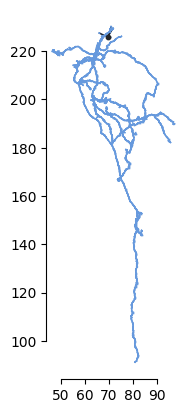

In [ ]:
plot_neuron(neighbors, features)

In [ ]:
MIN_NODES = 500  # skip severely-pruned skeletons
skipped = []

for cell_id in tqdm(neuron_ids):
    which_cell = neuron_ids.index(cell_id)
    file_name = file_list[which_cell]
    morphology = read_swc_file(file_name, correction=True)

    if len(morphology) < MIN_NODES:
        skipped.append((cell_id, len(morphology)))
        continue

    morphology['id'] = morphology['id'].astype(int)
    morphology['parent'] = morphology['parent'].astype(int)

    children_map = (morphology.loc[morphology['parent'] != -1]
                              .groupby('parent')['id']
                              .apply(list)
                              .to_dict())
    morphology['children'] = morphology['id'].apply(lambda _id: list(children_map.get(_id, [])))

    neighbors = {}
    idx2node = {}
    for i, item in enumerate(morphology.to_dict(orient='records')):
        sec_type = [0, 0, 0, 0]
        sec_type[item['type']] = 1
        feat = tuple([item['x'], item['y'], item['z'], item['radius']]) + tuple(sec_type)
        idx2node[i] = feat

        neighbors[i] = set(item['children'])
        if item['parent'] >= 0:
            neighbors[i].add(item['parent'])

    features = np.array(list(idx2node.values()))

    soma_pos = features[0, :3]
    norm_features = features.copy()
    norm_features[:, :3] = norm_features[:, :3] - soma_pos

    adj_matrix = neighbors_to_adjacency(neighbors, range(len(neighbors)))
    G = nx.Graph(adj_matrix)
    if nx.number_connected_components(G) > 1:
        adj_matrix, neighbors = connect_graph(adj_matrix, neighbors, features)

    assert len(neighbors) == len(adj_matrix)
    assert len(neighbors) == len(norm_features)
    assert ~np.any(np.isnan(norm_features))

    path = Path('./skeletons_no_axon/', str(cell_id))
    path.mkdir(parents=True, exist_ok=True)
    np.save(Path(path, 'features'), norm_features)
    with open(Path(path, 'neighbors.pkl'), 'wb') as f:
        pickle.dump(dict(neighbors), f, pickle.HIGHEST_PROTOCOL)

print(f"Skipped {len(skipped)} cells with < {MIN_NODES} nodes:")
for cid, n in skipped[:20]:
    print(f"  {cid}: {n} nodes")


In [17]:
# save randomly 50 neurons id as validation set and the rest as training set (val_ids.npy and train_ids.npy)
import random
random.seed(42)
val_size = 50
val_ids = random.sample(neuron_ids, val_size)
train_ids = [nid for nid in neuron_ids if nid not in val_ids]
np.save('val_ids.npy', np.array(val_ids))
np.save('train_ids.npy', np.array(train_ids))


In [18]:
np.save('all_ids.npy', np.array(neuron_ids))